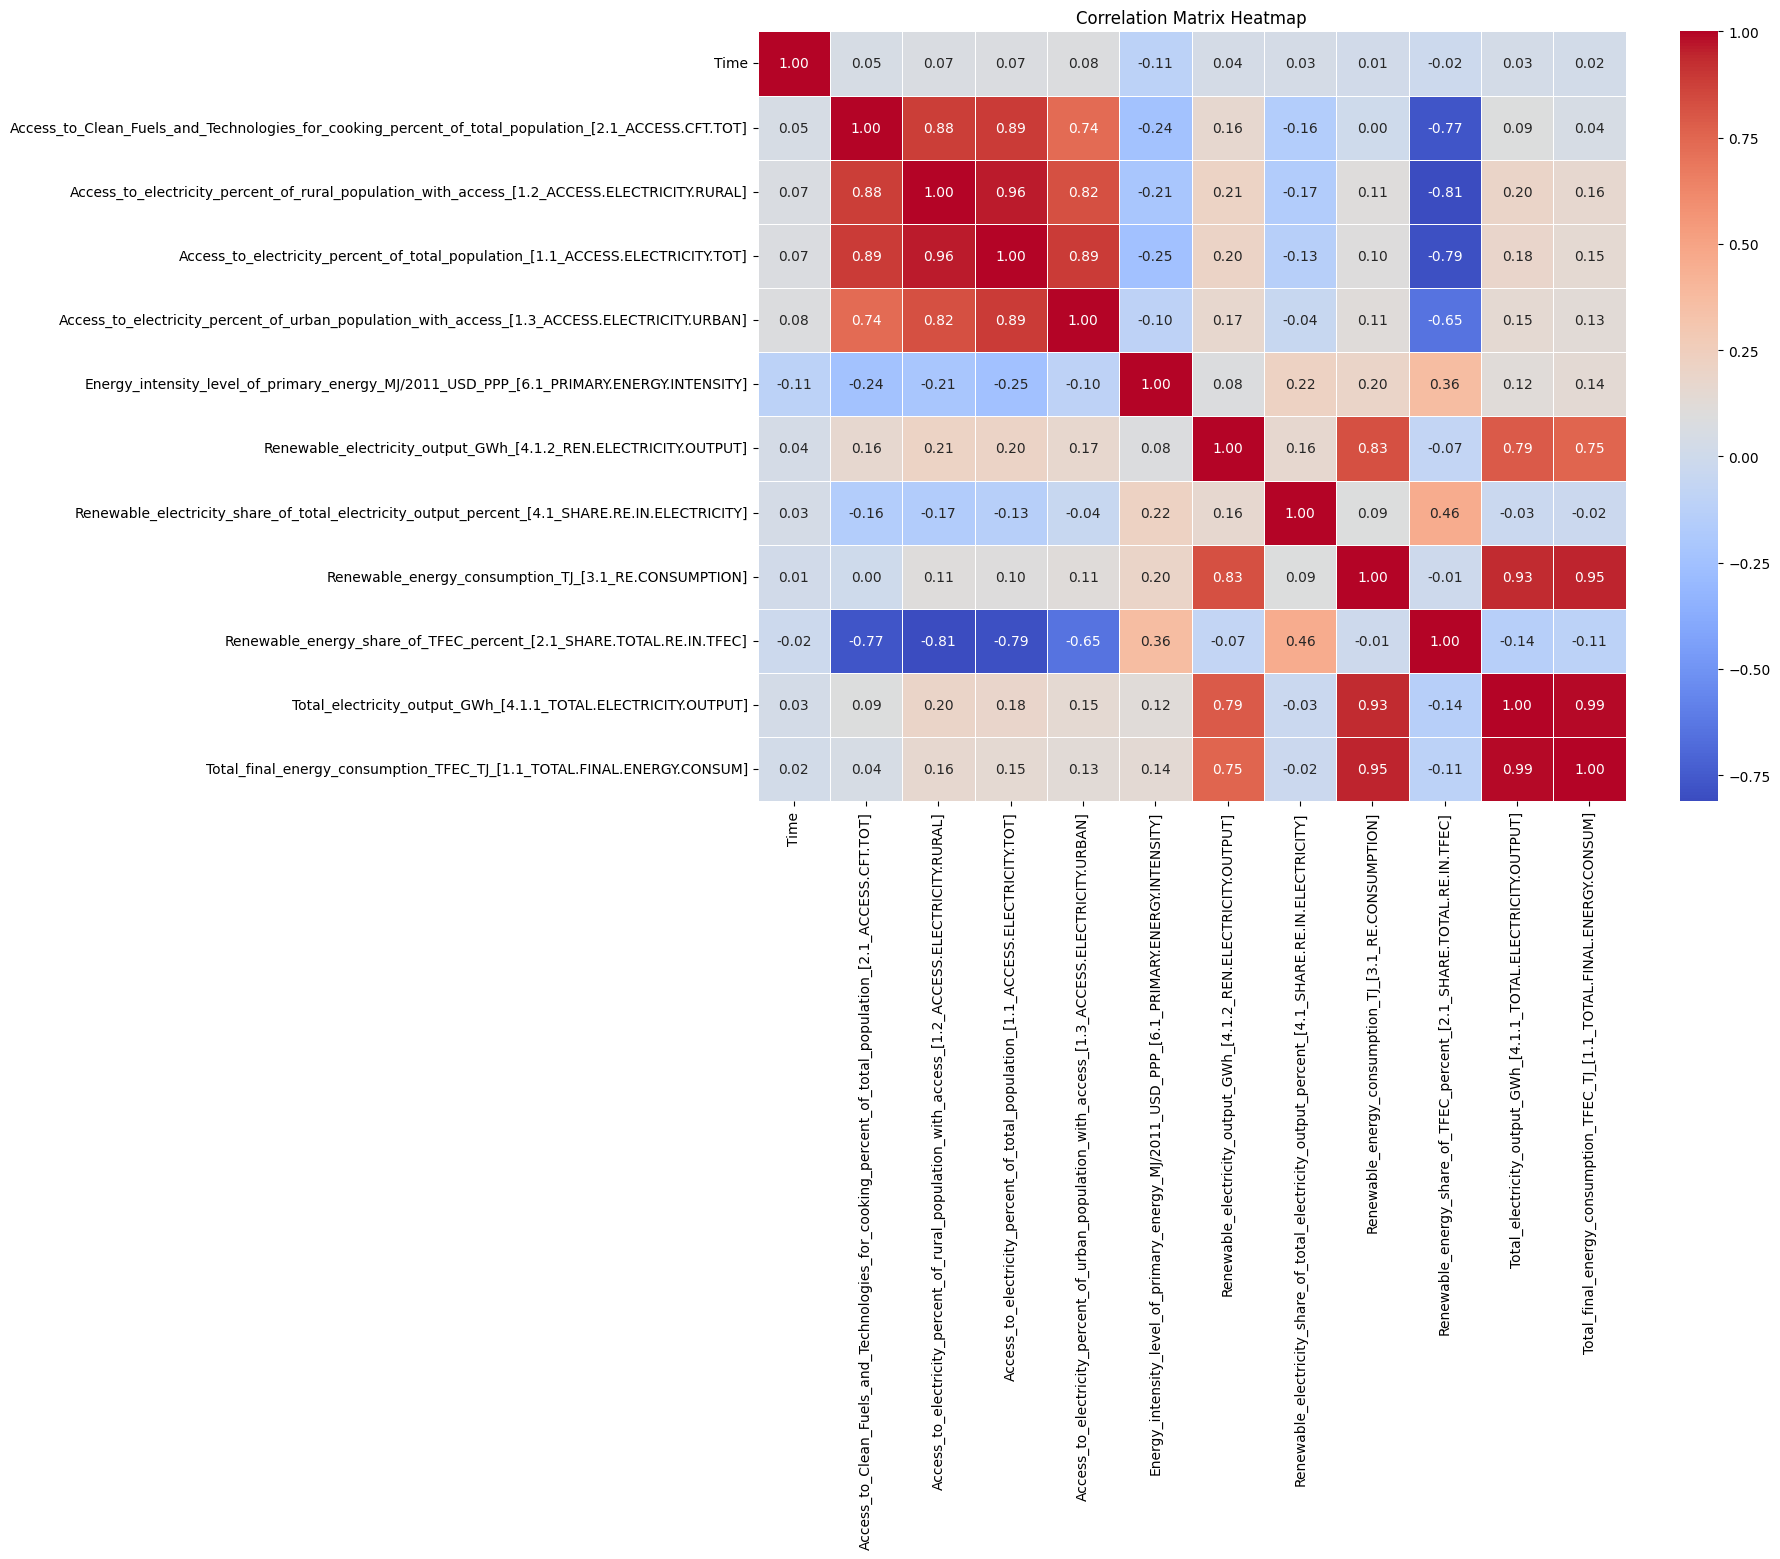


--- Variance Inflation Factor (VIF) Results ---
                                              Feature         VIF
12  Total_final_energy_consumption_TFEC_TJ_[1.1_TO...  283.579637
11  Total_electricity_output_GWh_[4.1.1_TOTAL.ELEC...  198.385617
9   Renewable_energy_consumption_TJ_[3.1_RE.CONSUM...   41.193980
4   Access_to_electricity_percent_of_total_populat...   28.738632
3   Access_to_electricity_percent_of_rural_populat...   15.945702
7   Renewable_electricity_output_GWh_[4.1.2_REN.EL...   11.675977
5   Access_to_electricity_percent_of_urban_populat...    6.319391
2   Access_to_Clean_Fuels_and_Technologies_for_coo...    6.170208
10  Renewable_energy_share_of_TFEC_percent_[2.1_SH...    5.119908
8   Renewable_electricity_share_of_total_electrici...    1.678460
6   Energy_intensity_level_of_primary_energy_MJ/20...    1.455019
1                                                Time    1.035833

Features with VIF > 10 (High Multicollinearity):
['Total_final_energy_consumption_TFEC_TJ_[1

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 1. Load the dataset
# If running in Colab, ensure you upload the file first
file_path = '/content/sample_data/preprocessed_energy_data.csv'
df = pd.read_csv(file_path)

# 2. Prepare Numeric Data
# We select only numeric columns and drop identifiers/categorical codes
numeric_df = df.select_dtypes(include=[np.number])

# Check for constant columns (VIF cannot be calculated if variance is 0)
constant_columns = [col for col in numeric_df.columns if numeric_df[col].nunique() <= 1]
if constant_columns:
    print(f"Dropping constant columns: {constant_columns}")
    numeric_df = numeric_df.drop(columns=constant_columns)

# 3. Generate Correlation Matrix Heatmap
plt.figure(figsize=(14, 10))
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

# 4. Calculate Variance Inflation Factor (VIF)
# We add a constant column for the intercept as required by statsmodels
X = add_constant(numeric_df)

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

# Remove the 'const' row and sort by VIF
vif_results = vif_data[vif_data['Feature'] != 'const'].sort_values(by="VIF", ascending=False)

print("\n--- Variance Inflation Factor (VIF) Results ---")
print(vif_results)

high_vif = vif_results[vif_results['VIF'] > 10]
if not high_vif.empty:
    print("\nFeatures with VIF > 10 (High Multicollinearity):")
    print(high_vif['Feature'].tolist())

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def reduce_vif(df, threshold=10.0):
    """
    Iteratively removes features with VIF > threshold.
    """
    # Select only numeric columns
    numeric_df = df.select_dtypes(include=[np.number])
    cols = numeric_df.columns.tolist()

    dropped_features = []

    while True:
        # Add a constant for the intercept
        X = add_constant(numeric_df[cols])

        # Calculate VIF for each feature
        vif_series = pd.Series(
            [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
            index=X.columns
        ).drop('const')

        max_vif = vif_series.max()

        if max_vif > threshold:
            feature_to_drop = vif_series.idxmax()
            print(f"Dropping '{feature_to_drop}' (VIF: {max_vif:.2f})")
            cols.remove(feature_to_drop)
            dropped_features.append(feature_to_drop)
        else:
            break

    # Reconstruct the dataframe with categorical columns and filtered numeric columns
    non_numeric = df.select_dtypes(exclude=[np.number]).columns.tolist()
    final_df = df[non_numeric + cols]

    print("\nReduction Complete.")
    print(f"Features Dropped: {dropped_features}")
    return final_df, vif_series

#  Load your dataset
df = pd.read_csv('/content/sample_data/preprocessed_energy_data.csv')

# 2. Run the reduction function
reduced_df, final_vifs = reduce_vif(df, threshold=10.0)

#  View final VIFs
print("\nFinal VIF Values:")
print(final_vifs)

#  Save the new dataset
reduced_df.to_csv('reduced_energy_data.csv', index=False)
print("\nReduced dataset saved as 'reduced_energy_data.csv'")

Dropping 'Total_final_energy_consumption_TFEC_TJ_[1.1_TOTAL.FINAL.ENERGY.CONSUM]' (VIF: 283.58)
Dropping 'Access_to_electricity_percent_of_total_population_[1.1_ACCESS.ELECTRICITY.TOT]' (VIF: 28.47)
Dropping 'Renewable_energy_consumption_TJ_[3.1_RE.CONSUMPTION]' (VIF: 10.47)

Reduction Complete.
Features Dropped: ['Total_final_energy_consumption_TFEC_TJ_[1.1_TOTAL.FINAL.ENERGY.CONSUM]', 'Access_to_electricity_percent_of_total_population_[1.1_ACCESS.ELECTRICITY.TOT]', 'Renewable_energy_consumption_TJ_[3.1_RE.CONSUMPTION]']

Final VIF Values:
Time                                                                                                   1.031146
Access_to_Clean_Fuels_and_Technologies_for_cooking_percent_of_total_population_[2.1_ACCESS.CFT.TOT]    5.136527
Access_to_electricity_percent_of_rural_population_with_access_[1.2_ACCESS.ELECTRICITY.RURAL]           8.107985
Access_to_electricity_percent_of_urban_population_with_access_[1.3_ACCESS.ELECTRICITY.URBAN]           3.284498
Energ